In [ ]:
#### Importing necessary libraries
import pandas as pd               # Data manipulation
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt    # Basic plotting
import seaborn as sns             # Advanced plotting
import plotly.express as px       # Interactive plots (optional)


In [5]:
# Import pandas
import pandas as pd

# Load your dataset
df = pd.read_csv('covid_19_clean_complete.csv')
df




,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [38]:
# Display the first few rows of the dataset to understand its structure
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df.shape #to check the shape of the data frame

(49068, 10)

In [8]:
df.dtypes # to check the data type of the data 

Province/State     object
Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object

In [9]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [10]:
df = df.drop(columns=['Province/State']) #droping the state province 



In [11]:
df #confirming the drop

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [13]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])
# Verify the conversion
print(df['Date'].head())


0   2020-01-22
1   2020-01-22
2   2020-01-22
3   2020-01-22
4   2020-01-22
Name: Date, dtype: datetime64[ns]


In [14]:
df.dtypes # now the date is in datetime_dtypes

Country/Region            object
Lat                      float64
Long                     float64
Date              datetime64[ns]
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
WHO Region                object
dtype: object

In [18]:
# Check Active cases consistency
inconsistent_rows = df[df['Active'] != df['Confirmed'] - (df['Deaths'] + df['Recovered'])]

if inconsistent_rows.empty:
    print("Active cases are consistent.")
else:
    print(f"Found {len(inconsistent_rows)} inconsistent rows in Active cases.")


Active cases are consistent.


In [ ]:
# Check for valid date range
if (df['Date'] >= '2019-12-01').all() and (df['Date'] <= pd.Timestamp.today()).all():
    print("All dates are valid and within range.")
else:
    print("There are invalid or out-of-range dates.")


In [19]:
# Check for valid date range
if (df['Date'] >= '2019-12-01').all() and (df['Date'] <= pd.Timestamp.today()).all():
    print("All dates are valid and within range.")
else:
    print("There are invalid or out-of-range dates.")


All dates are valid and within range.


In [20]:
# Check unique values for Country/Region
print("Unique countries/regions:", df['Country/Region'].nunique())
print("Unique WHO Regions:", df['WHO Region'].unique())


Unique countries/regions: 187
Unique WHO Regions: ['Eastern Mediterranean' 'Europe' 'Africa' 'Americas' 'Western Pacific'
 'South-East Asia']


In [21]:
# Global totals
total_confirmed = df['Confirmed'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()

print(f"Global Totals - Confirmed: {total_confirmed}, Deaths: {total_deaths}, Recovered: {total_recovered}")


Global Totals - Confirmed: 828508482, Deaths: 43384903, Recovered: 388408229


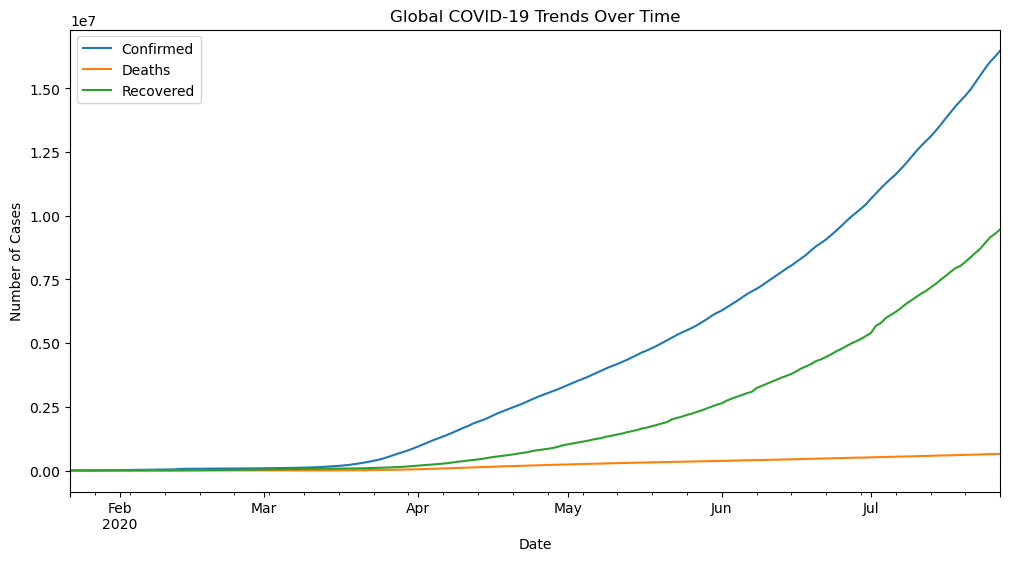

In [22]:
#Analyze trends in daily/weekly/monthly cases, deaths, and recoveries
import matplotlib.pyplot as plt
# Group by date and sum
trend_data = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot
trend_data.plot(figsize=(12, 6), title="Global COVID-19 Trends Over Time")
plt.ylabel("Number of Cases")
plt.xlabel("Date")
plt.show()


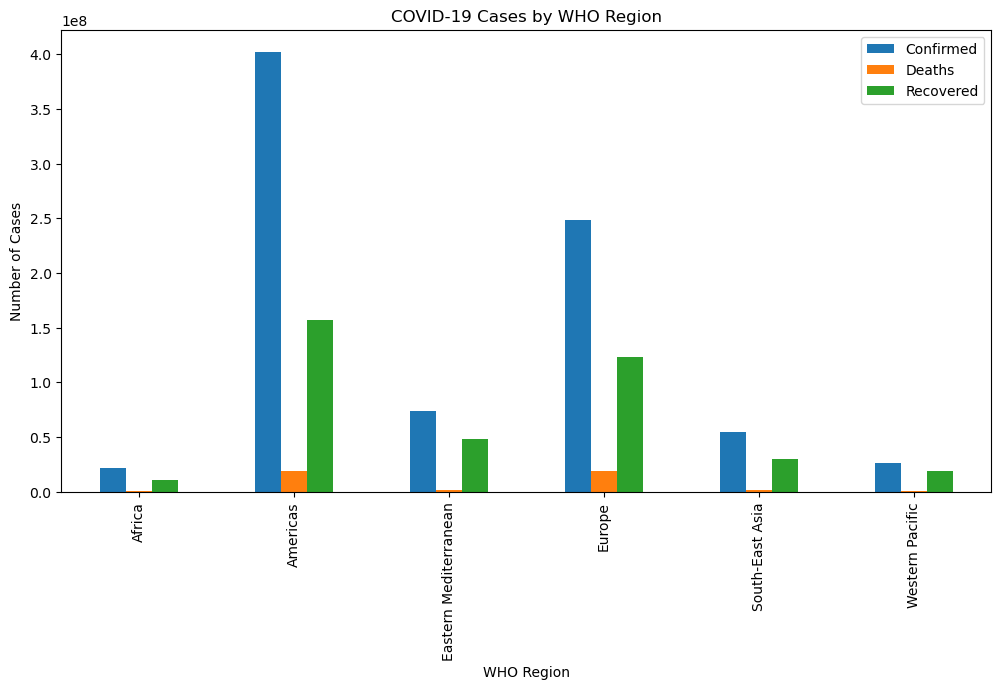

In [23]:
# Group by WHO Region
region_data = df.groupby('WHO Region')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot
region_data.plot(kind='bar', figsize=(12, 6), title="COVID-19 Cases by WHO Region")
plt.ylabel("Number of Cases")
plt.xlabel("WHO Region")
plt.show()


In [27]:
# Correlation matrix
correlation = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()

print("Correlation Matrix:\n", correlation)


Correlation Matrix:
            Confirmed    Deaths  Recovered    Active
Confirmed   1.000000  0.912361   0.895506  0.950255
Deaths      0.912361  1.000000   0.763090  0.891858
Recovered   0.895506  0.763090   1.000000  0.713088
Active      0.950255  0.891858   0.713088  1.000000


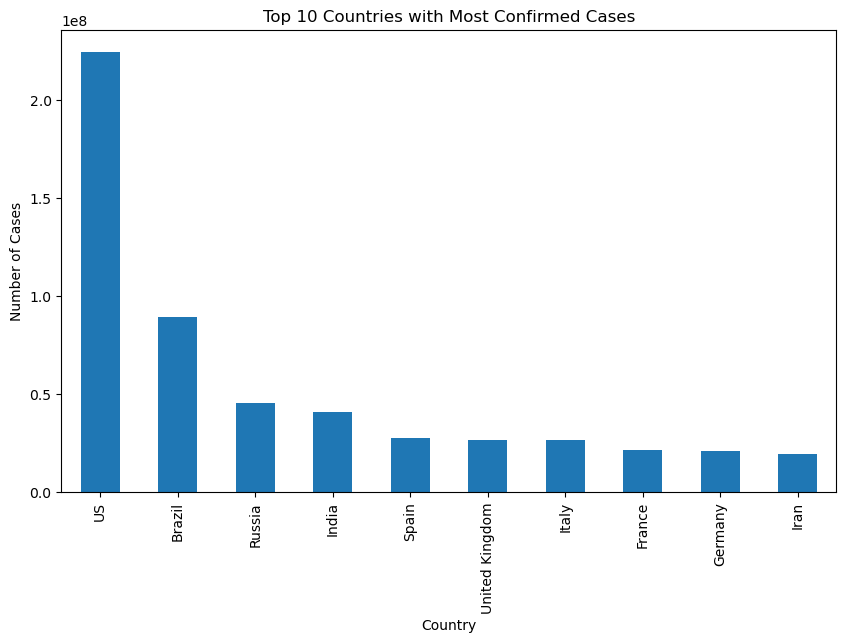

In [31]:
# COVID-19 trends across different countries, states, or regions.
# Group by Country/Region and get totals
country_data = df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

# Plot
country_data.plot(kind='bar', figsize=(10, 6), title="Top 10 Countries with Most Confirmed Cases")
plt.ylabel("Number of Cases")
plt.xlabel("Country")
plt.show()


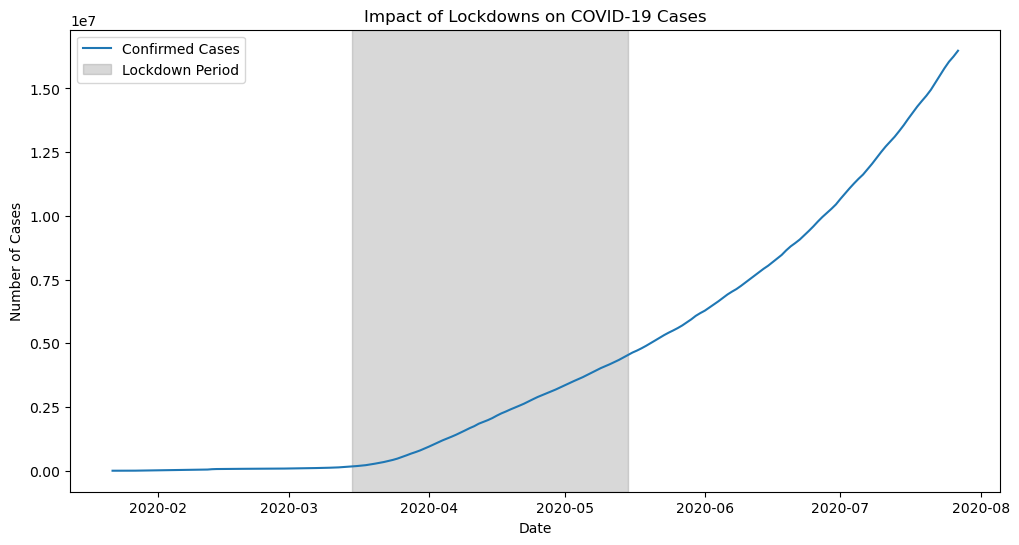

In [35]:
#
# Group data by Date
lockdown_data = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot trends
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(lockdown_data.index, lockdown_data['Confirmed'], label='Confirmed Cases')
plt.axvspan('2020-03-15', '2020-05-15', color='gray', alpha=0.3, label='Lockdown Period')
plt.title("Impact of Lockdowns on COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()


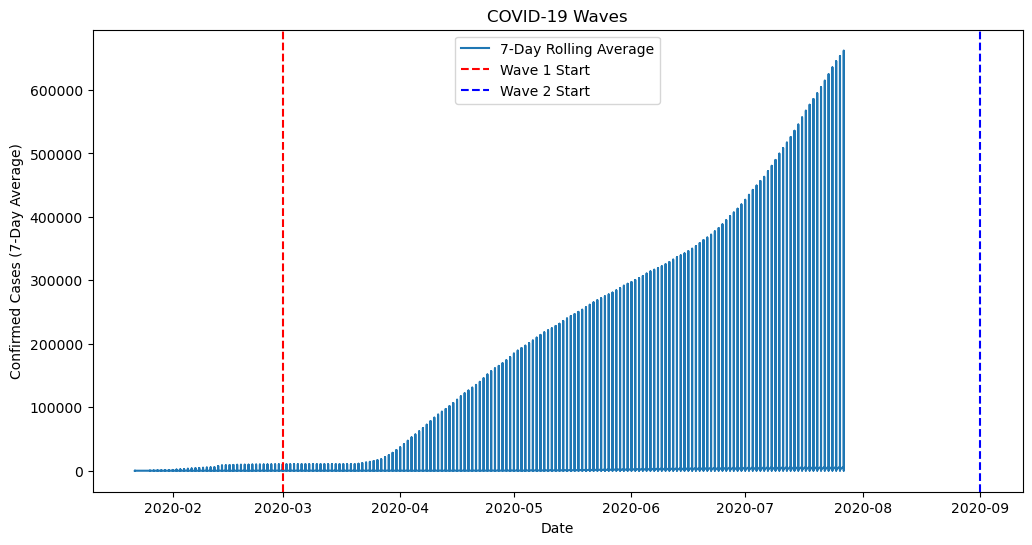

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Convert axvline dates to datetime
wave1_start = pd.to_datetime('2020-03-01')
wave2_start = pd.to_datetime('2020-09-01')

# Use the corrected dates for plotting
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['7-Day Average Cases'], label='7-Day Rolling Average')
plt.axvline(wave1_start, color='red', linestyle='--', label='Wave 1 Start')
plt.axvline(wave2_start, color='blue', linestyle='--', label='Wave 2 Start')
plt.title("COVID-19 Waves")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases (7-Day Average)")
plt.legend()
plt.show()


In [41]:
# Question 4 solution
'''"COVID-19 has been one of the most impactful global pandemics in recent history. This report analyzes data from the World Health Organization (WHO) to uncover insights into the virus's spread, the effectiveness of interventions like lockdowns and vaccinations, and the evolution of the pandemic.
"
'''

'"COVID-19 has been one of the most impactful global pandemics in recent history. This report analyzes data from the World Health Organization (WHO) to uncover insights into the virus\'s spread, the effectiveness of interventions like lockdowns and vaccinations, and the evolution of the pandemic.\n"\n'

In [43]:
'''"The dataset was cleaned to handle missing values in the Province/State column by droping the whole column."

'''

'"The dataset was cleaned to handle missing values in the Province/State column by droping the whole column."\n\n'

In [47]:
''' Key Insights
Break this section into subsections with visualizations.

Overall Trends

Line chart: Show global trends in confirmed cases, deaths, and recoveries.

Visualization Idea:

A line chart displaying daily/weekly trends in confirmed cases and deaths.'''

' Key Insights\nBreak this section into subsections with visualizations.\n\nOverall Trends\n\nLine chart: Show global trends in confirmed cases, deaths, and recoveries.\n\nVisualization Idea:\n\nA line chart displaying daily/weekly trends in confirmed cases and deaths.'

In [50]:
#Recommendations
'''Based on your analysis, provide actionable recommendations:

Public health policies: Emphasize timely lockdowns and vaccination campaigns.
International collaboration: Promote data sharing and resource pooling.
Healthcare system improvements: Expand ICU capacity and workforce training.'''

'Based on your analysis, provide actionable recommendations:\n\nPublic health policies: Emphasize timely lockdowns and vaccination campaigns.\nInternational collaboration: Promote data sharing and resource pooling.\nHealthcare system improvements: Expand ICU capacity and workforce training.'

In [52]:
# Conclusion
'''"Data-driven insights into COVID-19 have revealed the critical role of timely interventions, and international collaboration in managing pandemics. By leveraging these findings, we can strengthen our preparedness for future global health crises."
'''

'"Data-driven insights into COVID-19 have revealed the critical role of timely interventions, and international collaboration in managing pandemics. By leveraging these findings, we can strengthen our preparedness for future global health crises."\n'

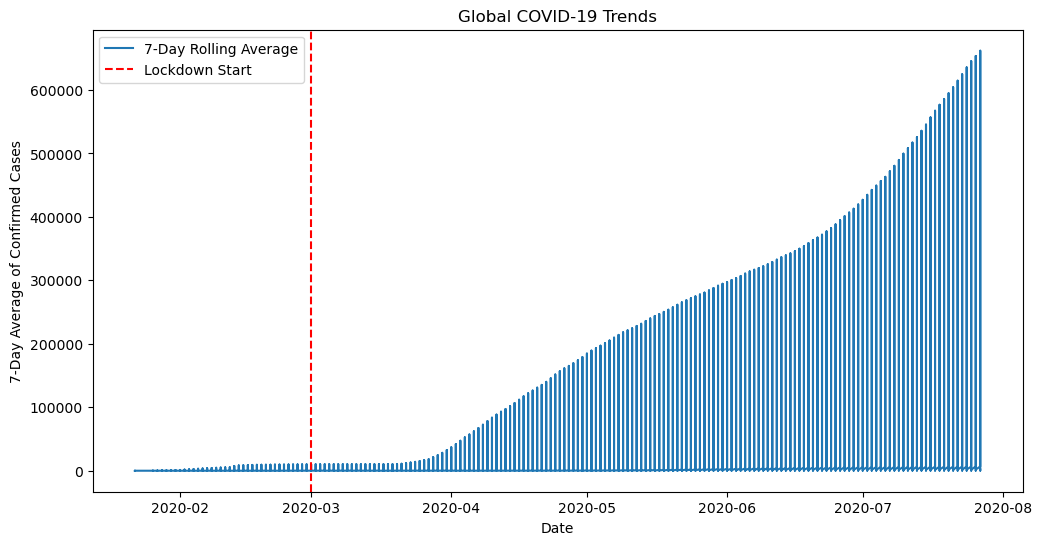

In [53]:
import matplotlib.pyplot as plt

# Example: Global confirmed cases over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['7-Day Average Cases'], label='7-Day Rolling Average')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Lockdown Start')
plt.title("Global COVID-19 Trends")
plt.xlabel("Date")
plt.ylabel("7-Day Average of Confirmed Cases")
plt.legend()
plt.show()


In [54]:
plt.savefig("Global COVID-19 Trends.png", dpi=300, bbox_inches='tight')  # Save plot
plt.show()  # Display the plot


<Figure size 640x480 with 0 Axes>